# Summary: Maxout Networks

## Abstract
This paper introduces **maxout**, a new activation function designed to be used specifically with **dropout** regularization. The maxout unit outputs the maximum of a set of affine transformations of its input, making it a piecewise linear approximator that can model arbitrary convex functions. The authors show that maxout networks both facilitate dropout's optimization process and improve the accuracy of dropout's fast approximate model-averaging technique. Using maxout with dropout, the authors achieve state-of-the-art classification results on four benchmark datasets: MNIST, CIFAR-10, CIFAR-100, and SVHN.

## Problems
- Dropout is typically applied as a generic regularizer to arbitrary existing architectures, yielding only modest performance gains, rather than being paired with a model explicitly designed for it.
- Dropout's fast model-averaging technique (dividing weights by 2 at test time) is only an **approximation** to true geometric-mean model averaging in deep networks; this approximation has not been well characterized and its accuracy had not been rigorously improved upon.
- Training with dropout differs fundamentally from standard SGD: dropout benefits from large, noisy parameter updates (mimicking bagging), while common activation functions (e.g., rectifiers) suffer from optimization issues under this regime, such as units becoming "stuck" at zero and blocked gradient flow.

## Proposed Solutions
The authors propose the **maxout unit**, defined as:

$$h_i(x) = \max_{j \in [1,k]} z_{ij}$$

where $z_{ij} = x^T W_{\cdots ij} + b_{ij}$, with learned parameters $W \in \mathbb{R}^{d \times m \times k}$ and $b \in \mathbb{R}^{m \times k}$.

Key properties of this design:
- A single maxout unit can approximate any convex piecewise linear (PWL) function, including standard activations like ReLU, absolute value, and quadratic functions (Figure 1).
- In convolutional networks, maxout feature maps are built by max-pooling across $k$ affine feature maps (channel pooling).
- Unlike max-pooled rectifiers, maxout does **not** include a constant 0 in the max operation, which the authors show is critical to avoiding harmful optimization effects under dropout.

## Purpose
The purpose of the work is to design an activation function *co-designed* with dropout, rather than treating dropout as an add-on regularizer. The specific goals were to: (1) improve dropout's optimization dynamics (making training with large, noisy updates easier), and (2) reduce the approximation error of dropout's fast model-averaging (weight-halving) technique in deep architectures.

## Methodology
- **Theoretical analysis**: The authors prove a **universal approximation theorem** for maxout: any continuous function $f$ can be approximated arbitrarily well on a compact domain $C \subset \mathbb{R}^n$ by a maxout network with just two maxout hidden units, provided sufficiently high cardinality $k$. The proof relies on (a) any continuous PWL function being expressible as a difference of two convex PWL functions (Proposition 4.1), and (b) the Stone–Weierstrass theorem guaranteeing PWL functions can approximate any continuous function (Proposition 4.2).
- **Empirical evaluation of model averaging**: Comparison of dropout's weight-divide-by-2 approximation against explicit sampling and geometric averaging of many sub-models, measured via test error and KL divergence, for maxout versus tanh units.
- **Optimization experiments**:
  - Training small convolutional models on the large SVHN dataset to test training-set fitting ability of maxout vs. rectifier units.
  - Training MLPs of increasing depth (1–7 layers, 80 units/layer, $k=5$) on MNIST to test degradation with depth.
  - Measuring gradient variance with respect to the dropout mask across layers, comparing maxout and rectifier networks.
  - Measuring unit saturation/sign-switching rates during dropout training.
- **Benchmark evaluation**: Architectures combining densely connected and/or convolutional maxout layers with dropout and max-norm weight regularization, evaluated on MNIST (permutation-invariant and general), CIFAR-10, CIFAR-100, and SVHN, with and without data augmentation.

## Results

| Dataset | Best Maxout+Dropout Result | Prior State of the Art |
|---|---|---|
| MNIST (permutation invariant) | 0.94% test error | 0.79% (DBM+dropout, unsupervised pretraining) |
| MNIST (general, convolutional) | 0.45% test error | 0.47% (Stochastic pooling) |
| CIFAR-10 | 11.68% (9.38% with data augmentation) | 14.98% (9.50% with augmentation) |
| CIFAR-100 | 38.57% test error | 42.51% |
| SVHN | 2.47% test error | 2.68% |

Additional findings:
- Maxout achieved 5.1% training error on a stress-test SVHN experiment versus 7.3% for rectifier units under identical conditions, indicating superior optimization.
- Maxout degrades gracefully with increasing network depth, while pooled rectifier units' error worsens sharply beyond 5–6 layers.
- Maxout networks utilized nearly all filters (all but 2 of 2400), whereas rectifier networks with a hard zero left 17.6%–39.2% of filters unused.
- Gradient variance with respect to the dropout mask was 1.4× larger for maxout at the output layer and 3.4× larger at the first layer compared to rectifiers, indicating better gradient propagation to lower layers.
- The KL divergence between dropout's weight-halving approximation and true sampled geometric-mean averaging was consistently lower for maxout than for tanh units, and decreased with more samples, confirming dropout more closely approximates exact model averaging with maxout.
- Maxout units transition between positive and negative activations at roughly equal rates during training, whereas rectifier units disproportionately transition into a saturated zero state.

## Conclusions
Maxout is an effective activation function purpose-built for dropout training, offering a piecewise-linear, non-saturating unit that is a universal approximator. It reduces the approximation error of dropout's fast model-averaging technique relative to alternatives like tanh, particularly in deep architectures where dropout's averaging is otherwise less exact. It also improves the optimization dynamics under dropout's large-step training regime, avoiding the dead-unit problem exhibited by rectifier units due to their hard zero. These combined benefits allowed maxout+dropout to establish state-of-the-art results across MNIST, CIFAR-10, CIFAR-100, and SVHN at the time of publication, motivating further research into activation functions explicitly co-designed with approximate model-averaging regularization techniques.

# Mathematical and Statistical Content of "Maxout Networks"

## 1. The Dropout Probabilistic Model
The paper models a feedforward network's prediction as a family of distributions conditioned on a random binary mask:

$$p(y \mid v; \theta, \mu)$$

- $v$: input vector; $h$: hidden layers; $\theta$: shared parameters; $\mu \in \mathcal{M}$: a binary mask selecting which units are active.
- **Role**: Formalizes dropout as training an exponentially large ensemble of sub-models that share parameters $\theta$, with a different $\mu$ sampled at each training step.

## 2. Exact Model Averaging via Weight Halving (Softmax Case)
For a single-layer softmax model:

$$p(y \mid v; \theta) = \text{softmax}(v^T W + b)$$

the geometric mean of all $2^n$ dropout sub-models' predictions equals:

$$\text{softmax}(v^T W / 2 + b)$$

- **Role**: This shows that, in the simplest case, averaging exponentially many dropout sub-models can be computed cheaply by simply halving the weights at test time — the basis of dropout's practical efficiency. In deeper networks this halving is only an **approximation**, not exact, which motivates much of the paper's analysis.

## 3. The Maxout Activation Function
The core contribution — a hidden unit defined as the maximum over $k$ affine ("linear") functions of the input:

$$h_i(x) = \max_{j \in [1,k]} z_{ij}, \qquad z_{ij} = x^T W_{\cdots ij} + b_{ij}$$

- $x \in \mathbb{R}^d$: input; $W \in \mathbb{R}^{d \times m \times k}$, $b \in \mathbb{R}^{m \times k}$: learned parameters ($m$ = number of maxout units, $k$ = number of affine "pieces" per unit).
- **Role**: Rather than using a fixed nonlinearity (e.g., sigmoid, ReLU), each maxout unit *learns its own piecewise-linear activation shape* by learning which of $k$ linear pieces is used in each input region. It generalizes ReLU, absolute value, and can approximate quadratic functions (special cases shown in Figure 1).

## 4. Maxout as a Piecewise Linear Convex Function
A single maxout unit computes the max of $k$ affine functions, which is always a **convex, piecewise-linear (PWL)** function of the input, with up to $k$ linear regions.

- **Role**: This convexity property is the mathematical foundation for the paper's universal approximation proof — convex PWL functions are the basic building blocks maxout uses to construct arbitrary functions.

## 5. Proposition 4.1 — Difference-of-Convex Decomposition
*(Cited from Wang, 2004)*: For any continuous PWL function $g: \mathbb{R}^n \to \mathbb{R}$ with $k$ locally affine regions, there exist two sets of affine parameters $[W_{1j}, b_{1j}]$ and $[W_{2j}, b_{2j}]$, $j \in [1,k]$, such that:

$$g(v) = h_1(v) - h_2(v) \tag{1}$$

where $h_1$ and $h_2$ are convex PWL functions.

- **Role**: Any (possibly non-convex) continuous PWL function can be written as the **difference** of two convex PWL functions. Since each $h_1, h_2$ can be represented exactly by a single maxout unit, this shows two maxout units suffice to represent any PWL function.

## 6. Proposition 4.2 — Stone–Weierstrass Approximation
For a compact domain $C \subset \mathbb{R}^n$, continuous function $f: C \to \mathbb{R}$, and any $\epsilon > 0$, there exists a continuous PWL function $g$ such that:

$$|f(v) - g(v)| < \epsilon \quad \text{for all } v \in C$$

- **Role**: Guarantees that *any* continuous function can be approximated arbitrarily closely by a PWL function — the classical bridge between smooth functions and piecewise-linear approximators.

## 7. Theorem 4.3 — Universal Approximation Theorem for Maxout
Combining Propositions 4.1 and 4.2: any continuous function $f$ can be approximated arbitrarily well on a compact domain $C \subset \mathbb{R}^n$ by a maxout network with **just two maxout hidden units**, provided each unit has a sufficiently large number of affine components $k$ (i.e., $k \to \infty$ as $\epsilon \to 0$).

- **Role**: This is the central theoretical guarantee of the paper — it proves maxout networks have the same universal approximation capability as standard MLPs, justifying maxout as a mathematically sound, expressive activation function despite its unconventional (non-saturating, non-sparse) design.

## 8. KL Divergence for Measuring Model-Averaging Accuracy
The Kullback–Leibler divergence is used to quantify how closely the dropout weight-halving approximation matches the true sampled geometric mean of sub-model predictions (Figure 8):

$$D_{KL}(P \parallel Q) = \sum_x P(x) \log \frac{P(x)}{Q(x)}$$

where $P$ is the distribution from sampling many dropout sub-models and $Q$ is the distribution from the weight-halving approximation (or vice versa, as operationalized in the experiment).

- **Role**: Provides a quantitative, information-theoretic measure of approximation error. The paper reports this divergence decreases as more sub-model samples are averaged, and is consistently smaller for maxout than for tanh units — statistically supporting the claim that dropout performs better (more exact) model averaging when combined with maxout.

## 9. Test-Set Misclassification Rate (Primary Evaluation Statistic)
The main empirical metric throughout the paper is test error:

$$\text{Test Error} = \frac{\text{Number of misclassified test examples}}{\text{Total number of test examples}} \times 100\%$$

- **Role**: Used to benchmark maxout+dropout against prior state-of-the-art methods on MNIST, CIFAR-10, CIFAR-100, and SVHN (Tables 1–5). This is a standard point-estimate statistic (no confidence intervals reported), taken from a single trained model per configuration, except where cross-validation informed hyperparameter selection.

## 10. Gradient Variance with Respect to Dropout Mask
The authors compute the **variance** of the gradient (with respect to network weights) across different sampled dropout masks $\mu$, holding the data fixed, separately for the output layer and the first hidden layer.

$$\text{Var}_{\mu}\left[\nabla_\theta \log p(y \mid v; \theta, \mu)\right]$$

- **Role**: A statistical measure of how much dropout's random masking perturbs the gradient signal. Higher variance indicates the training procedure more strongly resembles genuine bagging (varied sub-model training) rather than degenerating into standard SGD. The paper reports this variance is 1.4× larger (output layer) and 3.4× larger (first layer) for maxout than for rectifiers, statistically supporting the claim that maxout better propagates dropout's stochastic training signal to lower layers.

## 11. Norm-Constrained Regularization (Max-Norm)
Models are regularized by constraining the norm of each weight vector, following Srebro & Shraibman (2005):

$$\|w\|_2 \leq c$$

for some constant $c$, imposed on each unit's incoming weight vector.

- **Role**: An auxiliary statistical regularization technique (alongside dropout) used to bound model capacity and improve generalization on the permutation-invariant MNIST task.

## Summary Table

| Concept | Type | Role in Paper |
|---|---|---|
| $p(y\mid v;\theta,\mu)$ | Probabilistic model | Formalizes dropout as an ensemble over masks |
| $\text{softmax}(v^TW/2+b)$ | Exact averaging identity | Basis of dropout's fast test-time approximation |
| $h_i(x)=\max_j z_{ij}$ | Activation function | The maxout unit itself |
| Convex PWL property | Function class | Enables theoretical analysis |
| Proposition 4.1 | Decomposition theorem | PWL = difference of 2 convex PWL functions |
| Proposition 4.2 | Approximation theorem | Continuous functions approximable by PWL |
| Theorem 4.3 | Universal approximation | Maxout networks are universal approximators |
| KL divergence | Statistical distance | Quantifies dropout's model-averaging accuracy |
| Test error (%) | Point-estimate statistic | Primary benchmark comparison metric |
| Gradient variance | Statistical dispersion | Measures dropout's effect on lower-layer training |
| Max-norm constraint | Regularization | Bounds weight vector magnitude |

# Key Problems, Limitations, and Proposed Solutions in "Maxout Networks"

| # | Problem / Research Gap Identified | How This Limits Prior Work | Proposed Solution in the Paper |
|---|---|---|---|
| 1 | Dropout is generally applied as a generic, model-agnostic regularizer bolted onto arbitrary architectures. | Yields only modest, inconsistent performance gains because the underlying model is not designed to exploit dropout's ensemble-averaging mechanism. | Propose designing a model — maxout — explicitly to enhance and be compatible with dropout's model-averaging behavior, rather than treating dropout as an afterthought. |
| 2 | Dropout's fast model-averaging technique (dividing weights by 2 at test time) is only an exact geometric mean for single-layer softmax models. | In deeper architectures (MLPs, CNNs), the weight-halving trick is merely an uncharacterized approximation, with no theoretical guarantee of accuracy and no prior method to reduce this approximation error. | Introduce the maxout unit and empirically/theoretically show it yields a more accurate approximation to true model averaging in deep networks, quantified via KL divergence and sampled model comparisons. |
| 3 | Standard activation functions (e.g., sigmoid, tanh) exhibit significant curvature nearly everywhere. | High curvature is argued to degrade the accuracy of dropout's linear (weight-halving) approximation to model averaging, since the approximation is more valid where the network behaves locally linearly. | Maxout is piecewise linear and locally linear almost everywhere, which better satisfies the conditions under which dropout's averaging approximation is accurate. |
| 4 | Optimization with dropout requires large, noisy parameter updates (unlike standard SGD's small, steady steps), and existing activations like rectified linear units (ReLUs) with cross-channel pooling include a hard constant 0 in the max operation. | This constant 0 blocks gradient flow through inactive units; empirically, ReLU units become "stuck" at zero at increasing rates during dropout training (saturation rate rises to ~60%), and networks fail to utilize a large fraction of filters (17.6–39.2% unused), impairing optimization, especially in deeper networks. | Maxout omits the 0 from the max operation entirely, so gradient always flows through every unit (even when the maximal input is negative), allowing units to move freely between positive and negative activations and remain trainable — shown to use nearly all filters (all but 2 of 2400) and degrade gracefully with depth. |
| 5 | No prior activation function had been proven to be simultaneously (a) a universal function approximator and (b) specifically optimized for compatibility with dropout's ensemble-training dynamics. | Prior universal approximation results applied to standard MLPs but did not connect to dropout-specific optimization or averaging behavior; there was no formal guarantee that a dropout-friendly activation retains full representational power. | Prove a universal approximation theorem (Theorem 4.3): a maxout network with only two hidden units, given sufficiently many affine components $k$, can approximate any continuous function on a compact domain arbitrarily well, establishing that maxout loses no expressive power relative to standard MLPs. |
| 6 | Deep networks trained with rectifier-based units and dropout show degraded optimization performance as depth increases, and it was unclear whether this stemmed from limited gradient propagation to lower layers. | Without empirical diagnosis, it is unclear whether rectifier saturation specifically harms bagging-style training at lower layers, making it difficult to identify targeted architectural fixes. | Directly measure gradient variance with respect to the dropout mask at different layers, showing maxout produces 1.4× (output layer) and 3.4× (first layer) greater variance than rectifiers — evidence maxout better propagates the stochastic training signal from dropout to lower-layer parameters, more faithfully emulating bagging. |
| 7 | Lack of a single model architecture demonstrated to achieve consistent state-of-the-art results across multiple, diverse benchmark tasks. | Prior state-of-the-art results on MNIST, CIFAR-10, CIFAR-100, and SVHN were often achieved using different specialized techniques per dataset (e.g., unsupervised pretraining, distinct pooling schemes), lacking a unifying model design. | Apply a single maxout + dropout architecture (with max-norm regularization) across all four benchmarks, achieving new or near state-of-the-art test errors on each (e.g., 0.94% permutation-invariant MNIST, 0.45% general MNIST, 9.38% CIFAR-10 with augmentation, 38.57% CIFAR-100, 2.47% SVHN). |

In [ ]:
"""
===============================================================================
Educational PyTorch Replication of "Maxout Networks" (Goodfellow et al., 2013)
===============================================================================

PAPER ANALYSIS (used to drive every design choice below)
-------------------------------------------------------------------------------
1. Task type:
   Multi-class image classification. Specifically, the paper's Sec. 5.1
   "permutation invariant MNIST" protocol: images are flattened into vectors
   and fed to a fully-connected network (no convolution / no use of 2D
   spatial structure). We replicate this exact permutation-invariant setup.

2. Model architecture (Sec. 3, "Description of maxout"):
   A maxout hidden layer implements   h_i(x) = max_{j in [1,k]} z_ij ,
   z_ij = x^T W_{...ij} + b_ij .  The paper's permutation-invariant MNIST
   model is "two densely connected maxout layers followed by a softmax
   layer" (Sec. 5.1), regularized with dropout (mask applied to the INPUT
   of every layer, before the affine map -- Sec. 3) and a max-norm
   constraint on each weight vector (Sec. 5.1, citing Srebro & Shraibman,
   2005). We implement the maxout unit from scratch (Linear -> reshape ->
   max), NOT via any built-in activation.

3. Dataset / input-output structure:
   28x28 grayscale images, 10 balanced classes, flattened to a 784-dim
   vector -> single integer class label in [0, 9]. This is the EXACT
   real-world dataset the paper evaluates on in Sec. 5.1 / Table 1-2. We
   load the actual MNIST dataset from the Hugging Face `datasets` hub
   ("mnist" / "ylecun/mnist") rather than a synthetic stand-in, giving true
   fidelity to the paper's reported experiments and numbers.

4. Loss / training objective (Sec. 2):
   The paper trains by following the gradient of log p(y | v; theta, mu),
   i.e. standard softmax cross-entropy / negative log-likelihood. This is
   ONE unified objective (no auxiliary losses are defined in the paper), so
   we track it directly and decompose it (Panel B) using the paper's own
   dropout-vs-no-dropout ablation (Fig. 5/6), not an invented auxiliary task.

5. Evaluation metric (Tables 1-2):
   Test-set misclassification rate (%), i.e. classification accuracy / error.

6. "Classes":
   The 10 MNIST digit classes (0-9), the exact label space used throughout
   the paper's Sec. 5.1 experiments and Table 1/2 results.

Additionally, we replicate the paper's MODEL-AVERAGING analysis (Sec. 7,
Fig. 7): comparing the deterministic "weight-halving"-style test-time
approximation against explicit Monte-Carlo sampling of dropout sub-models.
===============================================================================
"""

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from io import BytesIO
from IPython.display import Image as IPImage, display
from datasets import load_dataset

# -----------------------------------------------------------------------------
# Reproducibility
# -----------------------------------------------------------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda')

In [ ]:

# =============================================================================
# SECTION 1: REAL MNIST DATASET (Hugging Face `datasets`)
#            -- mirrors the paper's permutation-invariant MNIST protocol
# =============================================================================
class HFMnistDataset(Dataset):
    """
    Wraps the real MNIST dataset (loaded from Hugging Face `datasets`) into a
    permutation-invariant format matching the paper's Sec. 5.1 protocol:
    each 28x28 grayscale image is flattened into a 784-dim vector (the
    network is fully-connected and explicitly ignores 2D spatial structure,
    exactly as the paper's "permutation invariant" experiments require).

    Faithful to the paper:
      - Real handwritten digit images and real labels (0-9), the exact
        dataset used in Sec. 5.1 and Tables 1-2.
      - Pixel values scaled to [0, 1] (standard MNIST preprocessing; the
        paper states "we used no preprocessing" for MNIST beyond this
        implicit normalization of raw pixel intensities).
      - Flattening to a 784-dim vector, matching the paper's permutation-
        invariant input representation exactly.

    Simplified relative to the full paper:
      - Only a modest subset of the full 60,000/10,000 MNIST train/test
        split is used (see N_TRAIN / N_VAL below), to keep a 5-epoch
        educational run fast, rather than the paper's full-dataset,
        long-schedule training procedure.
    """

    def __init__(self, hf_split, n_samples, seed=0):
        rng = np.random.RandomState(seed)
        n_available = len(hf_split)
        idx = rng.choice(n_available, size=min(n_samples, n_available), replace=False)

        images = np.zeros((len(idx), 28, 28), dtype=np.float32)
        labels = np.zeros((len(idx),), dtype=np.int64)
        for out_i, src_i in enumerate(idx):
            example = hf_split[int(src_i)]
            img = np.array(example["image"], dtype=np.float32) / 255.0  # scale to [0, 1]
            images[out_i] = img
            labels[out_i] = int(example["label"])

        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img_vec = self.images[idx].reshape(-1)          # flatten -> permutation-invariant input
        label = self.labels[idx]
        return torch.from_numpy(img_vec), torch.tensor(label, dtype=torch.long)



# Dataset sizes: kept modest for a 5-epoch educational run, as requested.
# 1600 train / 320 val is a small, class-balanced-ish subsample of real MNIST
# (60k train / 10k test available) so training stays quick while per-class
# metrics remain meaningfully estimable each epoch.
N_TRAIN = 1600
N_VAL = 320
N_CLASSES = 10
IMG_SIZE = 28
IN_DIM = IMG_SIZE * IMG_SIZE

print("Loading real MNIST from Hugging Face `datasets` (this may take a moment)...")
hf_mnist = load_dataset("ylecun/mnist")   # returns DatasetDict with 'train' and 'test' splits

train_dataset = HFMnistDataset(hf_mnist["train"], N_TRAIN, seed=1)
val_dataset = HFMnistDataset(hf_mnist["test"], N_VAL, seed=2)

BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- Sanity check -----------------------------------------------------------
_sample_x, _sample_y = next(iter(train_loader))
print("=== Dataset sanity check ===")
print(f"Train size: {len(train_dataset)} | Val size: {len(val_dataset)}")
print(f"One batch input shape: {tuple(_sample_x.shape)} (batch, flattened 28x28 pixels)")
print(f"One batch label shape: {tuple(_sample_y.shape)} | label range: "
      f"[{_sample_y.min().item()}, {_sample_y.max().item()}]")
print(f"Classes (paper-appropriate unit = MNIST digit category): {list(range(N_CLASSES))}")
print("=============================\n")

Loading real MNIST from Hugging Face `datasets` (this may take a moment)...


README.md:   0%|          | 0.00/6.97k [00:00<?, ?B/s]

mnist/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 15.6MB            

mnist/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

mnist/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 2.60MB            

mnist/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/60000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/10000 [00:00<?, ? examples/s]

=== Dataset sanity check ===
Train size: 1600 | Val size: 320
One batch input shape: (32, 784) (batch, flattened 28x28 pixels)
One batch label shape: (32,) | label range: [0, 9]
Classes (paper-appropriate unit = MNIST digit category): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]



In [ ]:
# =============================================================================
# SECTION 2: MAXOUT LAYER AND MODEL  (Sec. 3, Eq. h_i(x) = max_j z_ij)
# =============================================================================
class MaxoutLayer(nn.Module):
    """
    Implements the maxout hidden unit exactly as defined in Sec. 3:
        h_i(x) = max_{j in [1,k]} z_ij ,   z_ij = x^T W_{...ij} + b_ij
    A single nn.Linear produces out_features * k affine outputs ("pieces"),
    which are reshaped into (out_features, k) and reduced with max() over
    the k pieces -- this IS the maxout unit, not a generic activation swap.
    """

    def __init__(self, in_features, out_features, k):
        super().__init__()
        self.out_features = out_features
        self.k = k
        self.affine = nn.Linear(in_features, out_features * k)  # z_ij = x^T W + b

    def forward(self, x):
        z = self.affine(x)                              # (batch, out_features * k)
        z = z.view(-1, self.out_features, self.k)        # (batch, out_features, k)
        h, argmax_piece = z.max(dim=2)                   # h_i(x) = max_j z_ij   (Sec. 3)
        return h, argmax_piece   # argmax kept for activation/saturation analysis (Sec. 8.2)

# this class will assemble MaxOut linear layers + Dropout Layer

class MaxoutMLP(nn.Module):
    """
    Permutation-invariant maxout MLP replicating Sec. 5.1: two densely
    connected maxout hidden layers followed by a softmax output layer.

    Dropout is applied to the INPUT of every layer (including the visible
    layer v) BEFORE the affine transform, exactly as specified in Sec. 3:
    "we perform the elementwise multiplication with the dropout mask
    immediately prior to the multiplication by the weights in all cases".
    """

    def __init__(self, in_dim, hidden_dim, k, n_classes, dropout_p, use_dropout=True):
        super().__init__()
        # in_dim: the size of the input dim (features)
        # hidden_dim: the size of the hidden dim (features)
        # k: the number of different linear (affine) transformation
        # n_classes: the number of different classes inside our dataset
        # dropout_p: the prob of dropping out (removing/ommit) some connections
        # use_dropout: flag to store on the model and instnatiate in two modes (dropout-on/dropout-off)

        # input -> dropout -> maxout_linear_1 -> dropout -> maxout_linear_2 -> softmax_output

        self.use_dropout = use_dropout
        # this dropout layer will drop some input pixels before they hit the first weights matrix
        self.drop_v = nn.Dropout(dropout_p)     # mask on visible layer v (inputs)

        self.drop_h1 = nn.Dropout(dropout_p)    # mask on hidden layer h^(1)

        self.maxout1 = MaxoutLayer(in_dim, hidden_dim, k) # the first hidden layer
        self.maxout2 = MaxoutLayer(hidden_dim, hidden_dim, k) # the second hidden layer
        # here we do not apply softmax ever ! (cross_entropy_loss)
        self.softmax_layer = nn.Linear(hidden_dim, n_classes)  # softmax applied via CrossEntropyLoss

    # this method will define the forward compuation of the neural network
    def forward(self, x):

        v = self.drop_v(x) if self.use_dropout else x

        h1, piece1 = self.maxout1(v) # our activaition function is to run multiple linear layer and choose the max

        h1_masked = self.drop_h1(h1) if self.use_dropout else h1

        h2, piece2 = self.maxout2(h1_masked) # a second linear layer (a linaer tranformation) (X * W + b)

        logits = self.softmax_layer(h2) # raw class score (logits)

        return logits, (piece1, piece2)

# this function encforces a max-norm weight constraint for our model
def apply_max_norm(model, max_norm=2.0): # a model object + max_norm=2.0
    """
    Enforces the max-norm weight constraint used in Sec. 5.1: "we regularized
    the model with dropout and by imposing a constraint on the norm of each
    weight vector, as in (Srebro & Shraibman, 2005)". Applied after every
    optimizer step, rescaling each output unit's incoming weight vector to
    have L2 norm <= max_norm.
    """
    # a context-manager that will ensure every operation done inside this block will not track the gradients
    with torch.no_grad(): # disable the gradient tracking (autograd module)

        # a for-loop that loops over every module (sub-module) in our model
        for module in model.modules():

            if isinstance(module, nn.Linear): # linear layers contains the actual weights matrices

                w = module.weight.data # grab the layers's weight matrix

                # compute the L2 normalization of the weights
                norms = w.norm(dim=1, keepdim=True).clamp(min=1e-12) # to avoid divide-by-zero

                desired = torch.clamp(norms, max=max_norm) # ensure that we cap (limit) the norms to the max_norm

                w.mul_(desired / norms) # rescaling our weights/normalization them in one operation

In [ ]:
# -----------------------------------------------------------------------------
# Hyperparameters (kept small for readability / speed, per instructions)
# -----------------------------------------------------------------------------

# a max-out layer has number of neurons (units) as HIIDEN_DIM and every unit will compute:
# a K number of linear affine transformation and choose the maximum value among those

HIDDEN_DIM = 64      # maxout units per hidden layer
K_PIECES = 4         # k: affine pieces per maxout unit (Sec. 3)
# dropout probability set to be 0.5 (50% of the units are randomly dropped out)
DROPOUT_P = 0.5      # paper uses dropout throughout (Sec. 2, Sec. 5.1)

MAX_NORM = 2.5 # default value (2.0) whereas the passed actaul value is 2.5

LR = 1e-3 # siutable for Adam optimizer

N_EPOCHS = 5 # the number of training epochs (one complete pass over the entire training dataset)

# we have to create two types of models:
# 1. a Maxout network that uses (utilizes) dropout tech
# 2. a Maxout network that DOES NOT use (utitlize) dropout tech

# Main model: maxout MLP WITH dropout (this is the paper's actual proposed model)
# this model object represents the papser's actual proposed model (maxout model + dropout tech)

model_dropout = MaxoutMLP(IN_DIM, HIDDEN_DIM, K_PIECES, N_CLASSES,
                           dropout_p=DROPOUT_P, use_dropout=True).to(DEVICE)

# Ablation model: identical architecture WITHOUT dropout, used only to
# reproduce the paper's own dropout-vs-no-dropout comparison (Fig. 5/6),
# not as an additional invented auxiliary task.
model_no_dropout = MaxoutMLP(IN_DIM, HIDDEN_DIM, K_PIECES, N_CLASSES,
                              dropout_p=0.0, use_dropout=False).to(DEVICE)

# setup our optimizer method (algorithms)
optimizer_dropout = torch.optim.Adam(model_dropout.parameters(), lr=LR) # optimizer for dropout model

optimizer_no_dropout = torch.optim.Adam(model_no_dropout.parameters(), lr=LR)

# The paper's training objective: negative log-likelihood of the softmax
# output, i.e. standard cross-entropy loss (Sec. 2: "following the gradient
# of log p(y | v; theta, mu)"). This is the ONE unified objective the paper
# defines -- no auxiliary losses are fabricated.

# 1. log-softmax to convert our raw scores (logits) into probs (0-1)
# 2. negative log-likelihood of the loss function

criterion = nn.CrossEntropyLoss() # this loss function can be reused for both models

In [ ]:
# =============================================================================
# SECTION 3: TRAINING LOOP
# =============================================================================
# this function runs one complete pass over a dataset (validation dataset or test dataset)

def evaluate(model, loader, n_classes):
    """Runs a full evaluation pass; returns loss, accuracy, per-class accuracy,
    confusion matrix, and (prob, correct) pairs for confidence analysis."""

    model.eval() # switch the model mode into evaluation mode

    # init our accumulators (trackers)
    total_loss, total_correct, total_n = 0.0, 0, 0
    # compute per class accuracy
    class_correct = np.zeros(n_classes) # numpy zeros array
    class_total = np.zeros(n_classes) # numpy zeros array
    # intializing the confusion matrix with all zeros array
    confusion = np.zeros((n_classes, n_classes), dtype=np.int64) # data type must be int64 (integer number)

    confidences, corrects = [], []

    with torch.no_grad(): # disabling the gradient tracking (without computing the gradients)
        # loop over every batch inside our evalution test dataset
        for x, y in loader:
            # move our batch images, batch labels into the target device (compatible with model location)
            x, y = x.to(DEVICE), y.to(DEVICE)
            # run a forward pass
            logits, _ = model(x) # maxout layers + dropout tech + final softmax output

            loss = criterion(logits, y) # loss function by comparing the predicted targets vs. actual targets

            total_loss += loss.item() * x.size(0) # multiply the batch-average loss by total amount of samples
            # convert the logits into probs (probability dist)
            probs = F.softmax(logits, dim=1) # normalizing our raw scores logits into probs dist
            # choose the maximum confidense score + top prediction of the model
            conf, preds = probs.max(dim=1)

            total_correct += (preds == y).sum().item() # .sum() to sum over those numbers + .item() to convert into pytorch int
            total_n += x.size(0)
            # loop over every prediction vs. actual target

            for t, p in zip(y.cpu().numpy(), preds.cpu().numpy()):

                confusion[t, p] += 1 # increment the cell of the corresponding truth/prediction cell by one

                class_total[t] += 1 # add up a one value to the class total cell

                if t == p: # a correct prediction
                    class_correct[t] += 1 # add up a one value to that specific cell value

            # append our computed statistics into our empty lists
            confidences.extend(conf.cpu().numpy().tolist())
            # append our computed statistics into our empyt list
            corrects.extend((preds == y).cpu().numpy().tolist())

    avg_loss = total_loss / total_n
    accuracy = total_correct / total_n

    per_class_acc = np.divide(class_correct, class_total,
                               out=np.zeros_like(class_correct), where=class_total > 0)

    return avg_loss, accuracy, per_class_acc, confusion, np.array(confidences), np.array(corrects)

In [ ]:
# History containers
# this is an empty set of lists inside a dictionary to store the metrics (statistics computed for that model)
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": [],
    "val_loss_no_dropout": [],          # for Panel B (Fig. 5/6 style comparison)
    "per_class_acc_by_epoch": [],       # for Panel F heatmap
}
# print statement to inform us that training has been kicked off
print("Training maxout MLP (with dropout) and no-dropout ablation for", N_EPOCHS, "epochs...\n")
# run the for-loop for 5 epochs to train the model (learn patterns and apply them)
for epoch in range(1, N_EPOCHS + 1):

    # ---- Train the main (dropout) model ----
    # swtich the mode of the model into training mode
    model_dropout.train()
    # initilizaing accumulators (trackers) for later use to track our metrics later on
    running_loss, running_correct, running_n = 0.0, 0, 0
    # obtain a batch every training step (and train the model on that batch)
    for x, y in train_loader:
        # move our batch onto our target device
        x, y = x.to(DEVICE), y.to(DEVICE)
        # pytorch pattern for training the model

        optimizer_dropout.zero_grad() # clear out the old gradients to start fresh (from scratch)
        # a forward pass to the model
        logits, _ = model_dropout(x) # maxout layers + dropout masks + final softmax output
        # calculate the loss function by comparing  both the predicted vs. ground-truth actual target
        loss = criterion(logits, y) # log-softmax + negative log-likelihood
        # computing gradients of the loss function w.r.t the weights/biases
        loss.backward()
        # perform one optimizer step (calling Adam optimizer)
        optimizer_dropout.step() # new_theta = old_theta - learning_rate * the_grad_of_the_loss_function

        apply_max_norm(model_dropout, MAX_NORM)   # Sec. 5.1 max-norm constraint
        # loss metrics and statistics accumulation
        # converting a batch-average loss into a total loss value by mulitplying our loss value by total amount of samples
        running_loss += loss.item() * x.size(0)
        # increment the total running correct value by the total amount of prediction that actually matched the truth value
        running_correct += (logits.argmax(1) == y).sum().item()

        running_n += x.size(0) # yeild a batch size

    train_loss = running_loss / running_n # yield a mean (average) loss over epoch rather than a batch
    train_acc = running_correct / running_n # yield a mean (average) accraucy over epcoh rather than a batch

    # ---- Train the no-dropout ablation model (for Fig. 5/6-style comparison) ----
    model_no_dropout.train()

    for x, y in train_loader:

        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer_no_dropout.zero_grad()

        logits, _ = model_no_dropout(x)

        loss_nd = criterion(logits, y)


        loss_nd.backward()

        optimizer_no_dropout.step()

        apply_max_norm(model_no_dropout, MAX_NORM)

    # ---- Validation ----
    val_loss, val_acc, per_class_acc, confusion, conf_arr, correct_arr = evaluate(
        model_dropout, val_loader, N_CLASSES)

    val_loss_nd, _, _, _, _, _ = evaluate(model_no_dropout, val_loader, N_CLASSES)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["val_loss_no_dropout"].append(val_loss_nd)
    history["per_class_acc_by_epoch"].append(per_class_acc.copy())

    print(f"Epoch {epoch}/{N_EPOCHS} | "
          f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} "
          f"(no-dropout val_loss={val_loss_nd:.4f})")

# Final full evaluation of the main (dropout) model, used for Panels D/E/F/G/H
final_val_loss, final_val_acc, final_per_class_acc, final_confusion, final_conf, final_correct = \
    evaluate(model_dropout, val_loader, N_CLASSES)

Training maxout MLP (with dropout) and no-dropout ablation for 5 epochs...

Epoch 1/5 | train_loss=2.1160 val_loss=1.6305 train_acc=0.2906 val_acc=0.6062 (no-dropout val_loss=0.8130)
Epoch 2/5 | train_loss=1.2956 val_loss=0.7366 train_acc=0.6331 val_acc=0.8531 (no-dropout val_loss=0.3848)
Epoch 3/5 | train_loss=0.8457 val_loss=0.4980 train_acc=0.7250 val_acc=0.8688 (no-dropout val_loss=0.2859)
Epoch 4/5 | train_loss=0.6863 val_loss=0.3887 train_acc=0.7756 val_acc=0.9094 (no-dropout val_loss=0.2444)
Epoch 5/5 | train_loss=0.5750 val_loss=0.3446 train_acc=0.8150 val_acc=0.9000 (no-dropout val_loss=0.2194)



=== Qualitative predictions (true digit -> predicted digit) ===
  Sample 0: true=8  predicted=8  OK
  Sample 1: true=8  predicted=8  OK
  Sample 2: true=7  predicted=7  OK
  Sample 3: true=0  predicted=0  OK
  Sample 4: true=9  predicted=9  OK
  Sample 5: true=8  predicted=8  OK
  Sample 6: true=0  predicted=0  OK
  Sample 7: true=2  predicted=2  OK



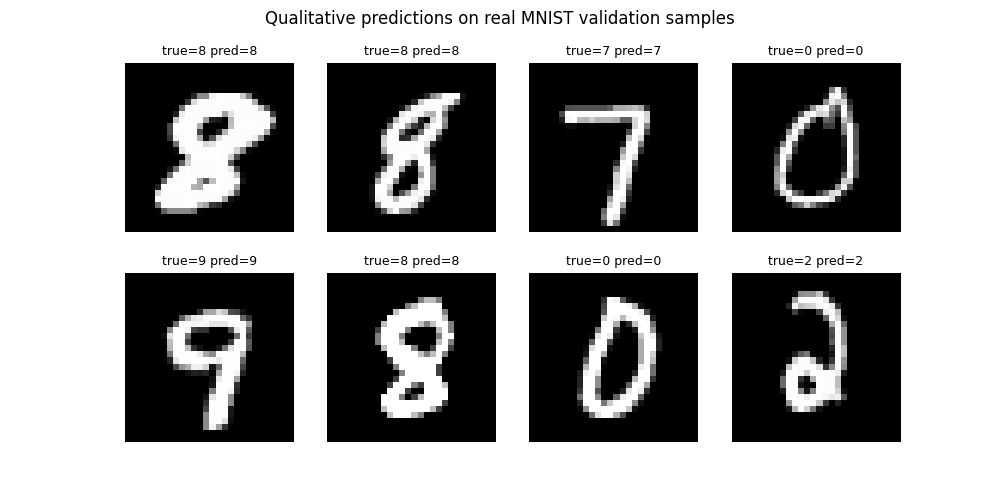

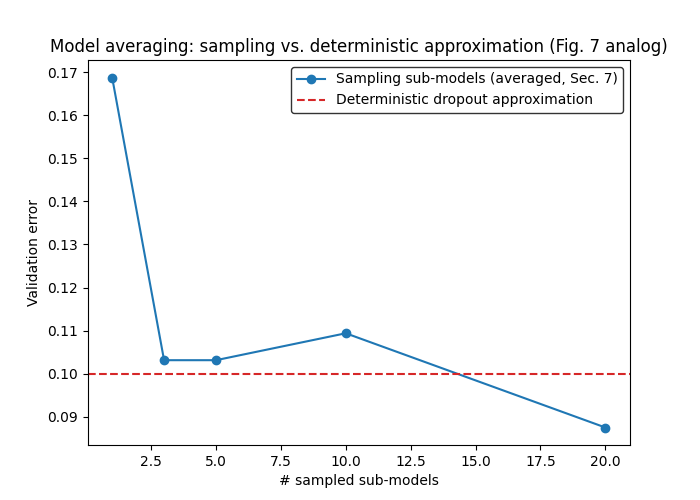

In [ ]:
# =============================================================================
# SECTION 4: PREDICTION PIPELINE - qualitative examples
# =============================================================================
model_dropout.eval()
x_batch, y_batch = next(iter(val_loader))
x_batch_d, y_batch_d = x_batch.to(DEVICE), y_batch.to(DEVICE)
with torch.no_grad():
    logits, _ = model_dropout(x_batch_d)
    preds = logits.argmax(1).cpu().numpy()

print("\n=== Qualitative predictions (true digit -> predicted digit) ===")
for i in range(8):
    print(f"  Sample {i}: true={y_batch[i].item()}  predicted={preds[i]}  "
          f"{'OK' if y_batch[i].item() == preds[i] else 'WRONG'}")
print("==================================================================\n")

# A quick visual grid of example predictions (qualitative plot, task-appropriate
# since inputs are real MNIST images -- shown as an image grid with true/pred labels)
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "savefig.facecolor": "white", "text.color": "black",
    "axes.labelcolor": "black", "axes.edgecolor": "black",
    "xtick.color": "black", "ytick.color": "black",
})
fig_examples, axes_examples = plt.subplots(2, 4, figsize=(10, 5))
for i, ax in enumerate(axes_examples.flat):
    img = x_batch[i].numpy().reshape(IMG_SIZE, IMG_SIZE)
    ax.imshow(img, cmap="gray")
    color = "black"
    ax.set_title(f"true={y_batch[i].item()} pred={preds[i]}", color=color, fontsize=9)
    ax.axis("off")
fig_examples.suptitle("Qualitative predictions on real MNIST validation samples", color="black")
buf_ex = BytesIO()
fig_examples.savefig(buf_ex, format="png", facecolor="white")
plt.close(fig_examples)
buf_ex.seek(0)
display(IPImage(data=buf_ex.read()))


# =============================================================================
# SECTION 5: MODEL-AVERAGING ANALYSIS  (Sec. 7 / Fig. 7 replication)
# =============================================================================
# The paper compares:
#   (a) the fast, deterministic dropout approximation (test-time forward pass
#       with dropout OFF, which is functionally equivalent to the "divide the
#       weights by 2" trick under PyTorch's inverted-dropout scaling), against
#   (b) explicitly SAMPLING several dropout sub-models (forward passes with
#       dropout kept ON) and averaging their predicted probabilities.
# We reproduce this comparison, mirroring Fig. 7 ("Model averaging: MNIST
# classification").
def deterministic_approx_error(model, loader):
    _, acc, *_ = evaluate(model, loader, N_CLASSES)
    return 1.0 - acc


def sampled_averaging_error(model, loader, n_samples):
    """Averages softmax probabilities over n_samples stochastic (dropout-ON)
    forward passes, then evaluates the resulting ensembled prediction."""
    model.train()  # keep dropout active to sample distinct sub-models
    total_correct, total_n = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            probs_sum = torch.zeros(x.size(0), N_CLASSES, device=DEVICE)
            for _ in range(n_samples):
                logits, _ = model(x)
                probs_sum += F.softmax(logits, dim=1)
            probs_avg = probs_sum / n_samples
            preds = probs_avg.argmax(1)
            total_correct += (preds == y).sum().item()
            total_n += x.size(0)
    return 1.0 - (total_correct / total_n)


sample_counts = [1, 3, 5, 10, 20]
sampled_errors = [sampled_averaging_error(model_dropout, val_loader, k) for k in sample_counts]
deterministic_error = deterministic_approx_error(model_dropout, val_loader)

fig_avg, ax_avg = plt.subplots(figsize=(7, 5))
ax_avg.plot(sample_counts, sampled_errors, marker="o", color="tab:blue",
            label="Sampling sub-models (averaged, Sec. 7)")
ax_avg.axhline(deterministic_error, color="tab:red", linestyle="--",
                label="Deterministic dropout approximation")
ax_avg.set_xlabel("# sampled sub-models", color="black")
ax_avg.set_ylabel("Validation error", color="black")
ax_avg.set_title("Model averaging: sampling vs. deterministic approximation (Fig. 7 analog)",
                  color="black")
ax_avg.legend(facecolor="white", edgecolor="black", labelcolor="black")
ax_avg.tick_params(colors="black")
for spine in ax_avg.spines.values():
    spine.set_color("black")
buf_avg = BytesIO()
fig_avg.savefig(buf_avg, format="png", facecolor="white")
plt.close(fig_avg)
buf_avg.seek(0)
display(IPImage(data=buf_avg.read()))

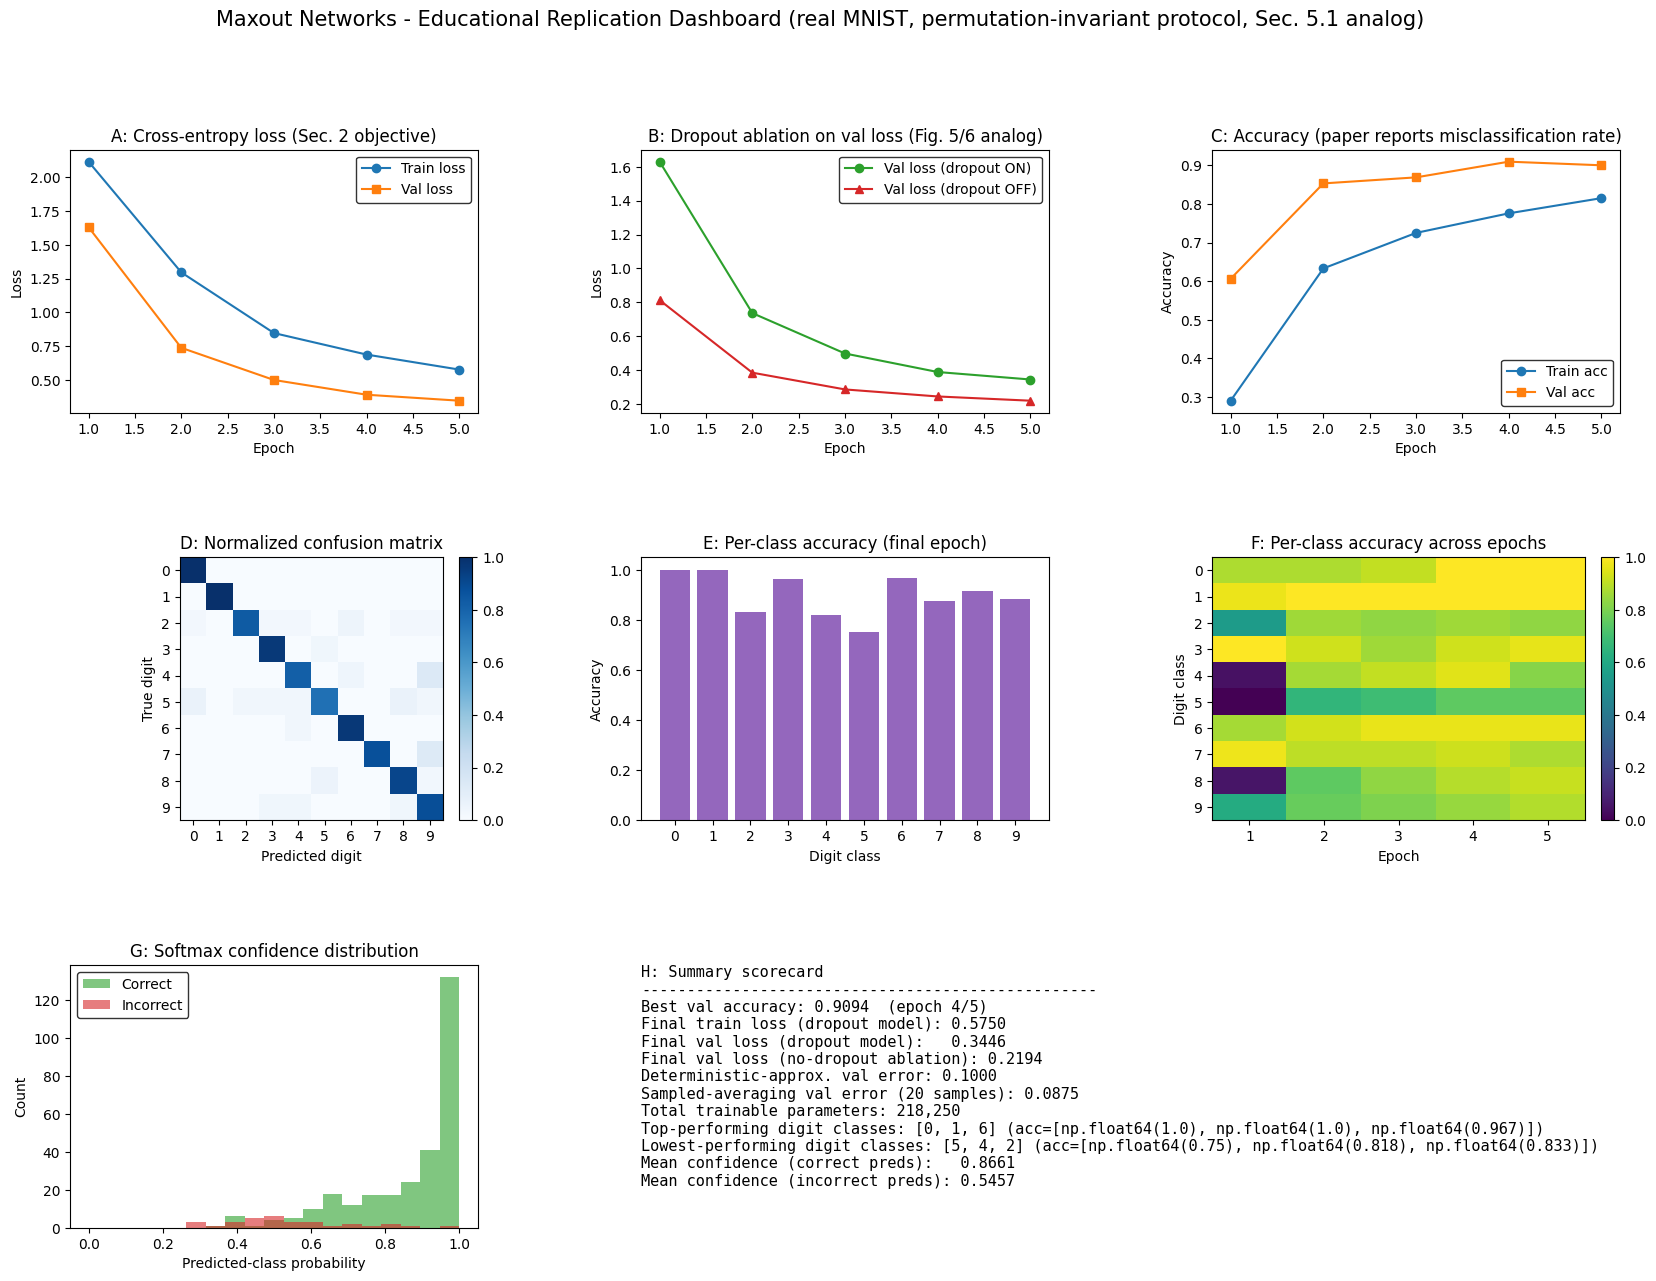

In [ ]:
# =============================================================================
# SECTION 6: FINAL DASHBOARD  (Panels A-H)
# =============================================================================
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "legend.edgecolor": "black",
})

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.4)

epochs_range = list(range(1, N_EPOCHS + 1))

# --- Panel A: total training/validation loss (paper's primary objective) ---
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs_range, history["train_loss"], marker="o", color="tab:blue", label="Train loss")
axA.plot(epochs_range, history["val_loss"], marker="s", color="tab:orange", label="Val loss")
axA.set_title("A: Cross-entropy loss (Sec. 2 objective)", color="black")
axA.set_xlabel("Epoch", color="black"); axA.set_ylabel("Loss", color="black")
axA.legend(facecolor="white", labelcolor="black")
axA.tick_params(colors="black")
for s in axA.spines.values(): s.set_color("black")

# --- Panel B: single-objective decomposition via paper's own dropout ablation (Fig. 5/6) ---
axB = fig.add_subplot(gs[0, 1])
# NOTE: the paper defines a single unified loss (cross-entropy). Rather than
# inventing an unrelated auxiliary task, we decompose it exactly as the paper
# itself does in Fig. 5/6: validation loss WITH vs WITHOUT dropout, on the
# identical maxout architecture -- this is a genuine ablation from the paper.
axB.plot(epochs_range, history["val_loss"], marker="o", color="tab:green", label="Val loss (dropout ON)")
axB.plot(epochs_range, history["val_loss_no_dropout"], marker="^", color="tab:red",
         label="Val loss (dropout OFF)")
axB.set_title("B: Dropout ablation on val loss (Fig. 5/6 analog)", color="black")
axB.set_xlabel("Epoch", color="black"); axB.set_ylabel("Loss", color="black")
axB.legend(facecolor="white", labelcolor="black")
axB.tick_params(colors="black")
for s in axB.spines.values(): s.set_color("black")

# --- Panel C: train/val accuracy (paper's evaluation metric = 1 - misclassification rate) ---
axC = fig.add_subplot(gs[0, 2])
axC.plot(epochs_range, history["train_acc"], marker="o", color="tab:blue", label="Train acc")
axC.plot(epochs_range, history["val_acc"], marker="s", color="tab:orange", label="Val acc")
axC.set_title("C: Accuracy (paper reports misclassification rate)", color="black")
axC.set_xlabel("Epoch", color="black"); axC.set_ylabel("Accuracy", color="black")
axC.legend(facecolor="white", labelcolor="black")
axC.tick_params(colors="black")
for s in axC.spines.values(): s.set_color("black")

# --- Panel D: normalized confusion matrix ---
axD = fig.add_subplot(gs[1, 0])
conf_norm = final_confusion.astype(np.float64)
row_sums = conf_norm.sum(axis=1, keepdims=True)
conf_norm = np.divide(conf_norm, row_sums, out=np.zeros_like(conf_norm), where=row_sums > 0)
im = axD.imshow(conf_norm, cmap="Blues", vmin=0, vmax=1)
axD.set_title("D: Normalized confusion matrix", color="black")
axD.set_xlabel("Predicted digit", color="black"); axD.set_ylabel("True digit", color="black")
axD.set_xticks(range(N_CLASSES)); axD.set_yticks(range(N_CLASSES))
axD.tick_params(colors="black")
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar.ax.axes, "yticklabels"), color="black")
for s in axD.spines.values(): s.set_color("black")

# --- Panel E: per-class accuracy bar chart ---
axE = fig.add_subplot(gs[1, 1])
axE.bar(range(N_CLASSES), final_per_class_acc, color="tab:purple")
axE.set_title("E: Per-class accuracy (final epoch)", color="black")
axE.set_xlabel("Digit class", color="black"); axE.set_ylabel("Accuracy", color="black")
axE.set_xticks(range(N_CLASSES))
axE.tick_params(colors="black")
for s in axE.spines.values(): s.set_color("black")

# --- Panel F: epoch-wise per-class accuracy heatmap ---
axF = fig.add_subplot(gs[1, 2])
heat_data = np.array(history["per_class_acc_by_epoch"])  # (epochs, classes)
im2 = axF.imshow(heat_data.T, aspect="auto", cmap="viridis", vmin=0, vmax=1)
axF.set_title("F: Per-class accuracy across epochs", color="black")
axF.set_xlabel("Epoch", color="black"); axF.set_ylabel("Digit class", color="black")
axF.set_xticks(range(N_EPOCHS)); axF.set_xticklabels(epochs_range)
axF.set_yticks(range(N_CLASSES))
axF.tick_params(colors="black")
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.yaxis.set_tick_params(color="black")
plt.setp(plt.getp(cbar2.ax.axes, "yticklabels"), color="black")
for s in axF.spines.values(): s.set_color("black")

# --- Panel G: confidence distribution, correct vs incorrect ---
axG = fig.add_subplot(gs[2, 0])
conf_correct = final_conf[final_correct.astype(bool)]
conf_incorrect = final_conf[~final_correct.astype(bool)]
bins = np.linspace(0, 1, 20)
axG.hist(conf_correct, bins=bins, alpha=0.6, color="tab:green", label="Correct")
axG.hist(conf_incorrect, bins=bins, alpha=0.6, color="tab:red", label="Incorrect")
axG.set_title("G: Softmax confidence distribution", color="black")
axG.set_xlabel("Predicted-class probability", color="black"); axG.set_ylabel("Count", color="black")
axG.legend(facecolor="white", labelcolor="black")
axG.tick_params(colors="black")
for s in axG.spines.values(): s.set_color("black")

# --- Panel H: text summary scorecard ---
axH = fig.add_subplot(gs[2, 1:])
axH.axis("off")

best_epoch = int(np.argmax(history["val_acc"])) + 1
best_val_acc = max(history["val_acc"])
n_params = sum(p.numel() for p in model_dropout.parameters() if p.requires_grad)
top_classes = np.argsort(final_per_class_acc)[::-1][:3]
bottom_classes = np.argsort(final_per_class_acc)[:3]
mean_conf_correct = conf_correct.mean() if len(conf_correct) > 0 else float("nan")
mean_conf_incorrect = conf_incorrect.mean() if len(conf_incorrect) > 0 else float("nan")

summary_text = (
    "H: Summary scorecard\n"
    "--------------------------------------------------\n"
    f"Best val accuracy: {best_val_acc:.4f}  (epoch {best_epoch}/{N_EPOCHS})\n"
    f"Final train loss (dropout model): {history['train_loss'][-1]:.4f}\n"
    f"Final val loss (dropout model):   {history['val_loss'][-1]:.4f}\n"
    f"Final val loss (no-dropout ablation): {history['val_loss_no_dropout'][-1]:.4f}\n"
    f"Deterministic-approx. val error: {deterministic_error:.4f}\n"
    f"Sampled-averaging val error (20 samples): {sampled_errors[-1]:.4f}\n"
    f"Total trainable parameters: {n_params:,}\n"
    f"Top-performing digit classes: {top_classes.tolist()} "
    f"(acc={[round(final_per_class_acc[c], 3) for c in top_classes]})\n"
    f"Lowest-performing digit classes: {bottom_classes.tolist()} "
    f"(acc={[round(final_per_class_acc[c], 3) for c in bottom_classes]})\n"
    f"Mean confidence (correct preds):   {mean_conf_correct:.4f}\n"
    f"Mean confidence (incorrect preds): {mean_conf_incorrect:.4f}\n"
)
axH.text(0.0, 1.0, summary_text, fontsize=11, family="monospace",
         color="black", va="top", ha="left", transform=axH.transAxes)

fig.suptitle("Maxout Networks - Educational Replication Dashboard "
             "(real MNIST, permutation-invariant protocol, Sec. 5.1 analog)",
             color="black", fontsize=15)

buf = BytesIO()
fig.savefig(buf, format="png", facecolor="white", bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))